# 11 — SOM Pixel Assignment

Load the trained SOM codebook from `10_som_training.ipynb`,
assign every valid pixel to its nearest BMU, and save the
landscape patch map.

**Input**: `final_som_codebook.pkl`, `som_production.index`,
feature stack from S3

**Output**: patch map saved to S3 Zarr

### Setup

In [2]:
import config
import gc
import json
import pickle
import numpy as np
import xarray as xr
import rioxarray
import s3fs
from s3_utils import load_zarr

# Load feature selection
with open('selected_features.json') as f:
    feature_names = json.load(f)
n_features = len(feature_names)

# Load scaler (fitted on all 21 features) and subset to selected
s3 = s3fs.S3FileSystem(anon=False)
prep = config.S3_PROCESSED + '/som_prep'
s3.get(f'{prep}/scaler.pkl', '/tmp/scaler.pkl')
with open('/tmp/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

s3.get(f'{prep}/feature_names.json', '/tmp/feature_names.json')
with open('/tmp/feature_names.json') as f:
    all_feature_names = json.load(f)

sel_idx = [all_feature_names.index(f) for f in feature_names]
scaler.center_ = scaler.center_[sel_idx]
scaler.scale_ = scaler.scale_[sel_idx]
scaler.n_features_in_ = n_features

# Grid metadata
s3.get(f'{prep}/grid_meta.json', '/tmp/grid_meta.json')
with open('/tmp/grid_meta.json') as f:
    grid_meta = json.load(f)
grid_shape = tuple(grid_meta['grid_shape'])
n_pixels = grid_meta['n_pixels']

# Valid indices
s3.get(f'{prep}/valid_indices.npy', '/tmp/valid_indices.npy')
valid_indices = np.load('/tmp/valid_indices.npy')
n_valid = len(valid_indices)

print(f'{n_features} features: {feature_names}')
print(f'Grid: {grid_shape}, valid: {n_valid:,} / {n_pixels:,}')


12 features: ['bio1', 'bio15', 'human_footprint', 'bio18', 'bio4', 'bio12', 'lc_built-up', 'ndvi_max', 'slope', 'canopy_height', 'forest_edge_dist', 'twi']
Grid: (9010, 17810), valid: 157,901,556 / 160,468,100


### Post-scale function (must match training)

In [3]:
def post_scale(X):
    """Domain-specific adjustments after RobustScaler."""
    X = X.copy()
    if 'forest_edge_dist' in feature_names:
        X[:, feature_names.index('forest_edge_dist')] = np.clip(
            X[:, feature_names.index('forest_edge_dist')], -5, 5)
    for name in feature_names:
        if name.startswith('lc_'):
            X[:, feature_names.index(name)] *= 3.0
    return np.clip(X, -5, 5)


### Assign and save in row-chunks

Process the grid in horizontal strips (e.g., 500 rows at a time).
Each strip is assigned, written to a local numpy memmap, and progress
is saved. If the connection drops, restart from the last completed strip.

In [4]:
import faiss
import time
import os

# Load model
index = faiss.read_index('som_production.index')
print(f'FAISS index: {index.ntotal} vectors')

# Load feature stack
ds = load_zarr(config.FEATURE_STACK_ZARR)
ref = ds[feature_names[0]]
n_rows, n_cols = grid_shape

# Output memmap — survives kernel restarts
MEMMAP_PATH = './.tmp/patch_map.dat'
ROW_CHUNK = 500
PROGRESS_PATH = './.tmp/patch_map_progress.txt'

# Create or resume memmap
if os.path.exists(MEMMAP_PATH) and os.path.exists(PROGRESS_PATH):
    patch_map = np.memmap(MEMMAP_PATH, dtype=np.int32, mode='r+', shape=(n_rows, n_cols))
    with open(PROGRESS_PATH) as f:
        start_row = int(f.read().strip())
    print(f'Resuming from row {start_row}')
else:
    patch_map = np.memmap(MEMMAP_PATH, dtype=np.int32, mode='w+', shape=(n_rows, n_cols))
    patch_map[:] = -1
    start_row = 0
    print('Starting fresh')

t0 = time.time()
total_assigned = 0

for row_start in range(start_row, n_rows, ROW_CHUNK):
    row_end = min(row_start + ROW_CHUNK, n_rows)

    # Load this strip of features
    strip = np.empty((row_end - row_start, n_cols, n_features), dtype=np.float32)
    for j, name in enumerate(feature_names):
        strip[:, :, j] = ds[name].values[row_start:row_end, :]

    # Flatten to (pixels_in_strip, n_features)
    flat = strip.reshape(-1, n_features)
    del strip

    # Find valid pixels (no NaN)
    valid = np.isfinite(flat).all(axis=1)
    valid_idx = np.where(valid)[0]

    if len(valid_idx) > 0:
        # Scale + post-process
        X_chunk = post_scale(scaler.transform(flat[valid_idx])).astype(np.float32)

        # FAISS nearest BMU
        _, labels = index.search(X_chunk, k=1)
        labels = labels.flatten().astype(np.int32)

        # Write to memmap
        strip_labels = np.full(flat.shape[0], -1, dtype=np.int32)
        strip_labels[valid_idx] = labels
        patch_map[row_start:row_end, :] = strip_labels.reshape(row_end - row_start, n_cols)
        total_assigned += len(valid_idx)

        del X_chunk, labels
    del flat

    # Save progress
    patch_map.flush()
    with open(PROGRESS_PATH, 'w') as f:
        f.write(str(row_end))

    elapsed = time.time() - t0
    pct = row_end / n_rows * 100
    eta = elapsed / max(pct, 0.1) * (100 - pct)
    if (row_start // ROW_CHUNK) % 2 == 0:
        print(f'  Rows {row_end:>5d}/{n_rows}  ({pct:5.1f}%)  '
              f'assigned={total_assigned:,}  elapsed={elapsed:.0f}s  ETA={eta:.0f}s')

elapsed = time.time() - t0
print(f'\nDone in {elapsed:.0f}s. Total assigned: {total_assigned:,}')


FAISS index: 4096 vectors
Resuming from row 9010

Done in 0s. Total assigned: 0


### Convert memmap to xarray and save to S3

In [5]:
from s3_utils import save_zarr

# Read the completed memmap
patch_map = np.memmap(MEMMAP_PATH, dtype=np.int32, mode='r', shape=(n_rows, n_cols))

patch_da = xr.DataArray(
    np.array(patch_map),  # copy from memmap to regular array
    dims=ref.dims, coords=ref.coords, name='patch_id',
).rio.write_crs('EPSG:4326')

save_zarr(patch_da, config.S3_PROCESSED + '/som/patch_map_30m.zarr', name='patch_id')
print(f'Saved: {patch_da.shape}, unique patches: {len(np.unique(patch_da.values[patch_da.values >= 0])):,}')

# Cleanup temp files
import os
#os.remove(MEMMAP_PATH)
#os.remove(PROGRESS_PATH)


/home/sagemaker-user/.conda/envs/cas/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Saved → s3://km-cas-datalake/processed/som/patch_map_30m.zarr
Saved: (9010, 17810), unique patches: 4,096


### Layer 2: Cluster the SOM codebook

The paper uses a *two-layer SOM*: the first layer maps pixels to BMUs,
the second layer clusters the BMU codebook vectors into a smaller number
of landscape types using hierarchical clustering (Ward's linkage).

This reduces 4096 BMU IDs → ~20–50 landscape types, producing much
larger and more ecologically coherent patches when we do connected-component
labelling in notebook 12.

Codebook: (4096, 12)
Computing Ward linkage...


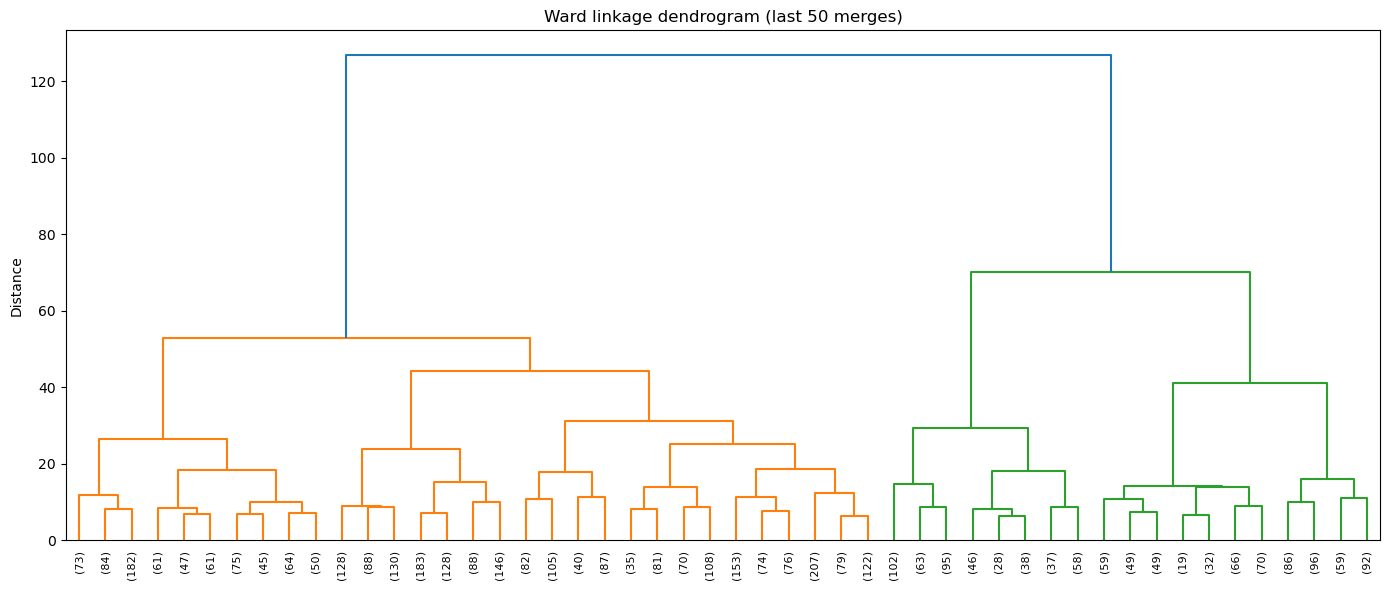

In [6]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
import matplotlib.pyplot as plt

# Load codebook
with open('final_som_codebook.pkl', 'rb') as f:
    cb = pickle.load(f)  # (4096, n_features)

print(f'Codebook: {cb.shape}')

# Ward's linkage on the 4096 codebook vectors
print('Computing Ward linkage...')
Z = linkage(cb, method='ward', metric='euclidean')

# Dendrogram to help choose the number of clusters
fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, truncate_mode='lastp', p=50, ax=ax,
           leaf_rotation=90, leaf_font_size=8)
ax.set_title('Ward linkage dendrogram (last 50 merges)')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()


In [7]:
# Choose number of landscape types — adjust based on dendrogram
N_LANDSCAPE_TYPES = 30

bmu_cluster_labels = fcluster(Z, t=N_LANDSCAPE_TYPES, criterion='maxclust')
bmu_cluster_labels -= 1  # 0-based

print(f'Clustered {cb.shape[0]} BMUs into {N_LANDSCAPE_TYPES} landscape types')
print(f'Cluster sizes: {np.bincount(bmu_cluster_labels)}')

# Remap the patch map: BMU ID → cluster label
# patch_map has values 0..4095 (valid) and -1 (nodata)
lut = bmu_cluster_labels.astype(np.int32)  # lookup table: bmu_id → cluster

pm = patch_da.values.copy()
valid = pm >= 0
pm[valid] = lut[pm[valid]]

cluster_da = xr.DataArray(
    pm, dims=patch_da.dims, coords=patch_da.coords, name='landscape_type',
).rio.write_crs('EPSG:4326')

# Check spatial coherence
same_right = (pm[:, :-1] == pm[:, 1:]) & (pm[:, :-1] >= 0)
same_down = (pm[:-1, :] == pm[1:, :]) & (pm[:-1, :] >= 0)
total_adj = (pm[:, :-1] >= 0).sum() + (pm[:-1, :] >= 0).sum()
same_adj = same_right.sum() + same_down.sum()
print(f'Adjacent same-type: {same_adj:,} / {total_adj:,} ({same_adj/total_adj*100:.1f}%)')

# Save
from s3_utils import save_zarr
save_zarr(cluster_da,
          config.S3_PROCESSED + '/som/landscape_types_30m.zarr',
          name='landscape_type')

# Save the lookup table for notebook 12
np.save('bmu_to_landscape_type.npy', lut)
print('Saved landscape type map and lookup table')


Clustered 4096 BMUs into 30 landscape types
Cluster sizes: [ 73 266 169 120 114 346 311  88 146  82 105  40  87 116 178 153 150 207
 201 102 158 112  95  59  98  51 136 182  59  92]
Adjacent same-type: 229,360,264 / 315,803,112 (72.6%)


/home/sagemaker-user/.conda/envs/cas/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Saved → s3://km-cas-datalake/processed/som/landscape_types_30m.zarr
Saved landscape type map and lookup table


### Visualize

/tmp/ipykernel_13782/3601917282.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cm = plt.cm.get_cmap('tab20', n_types)


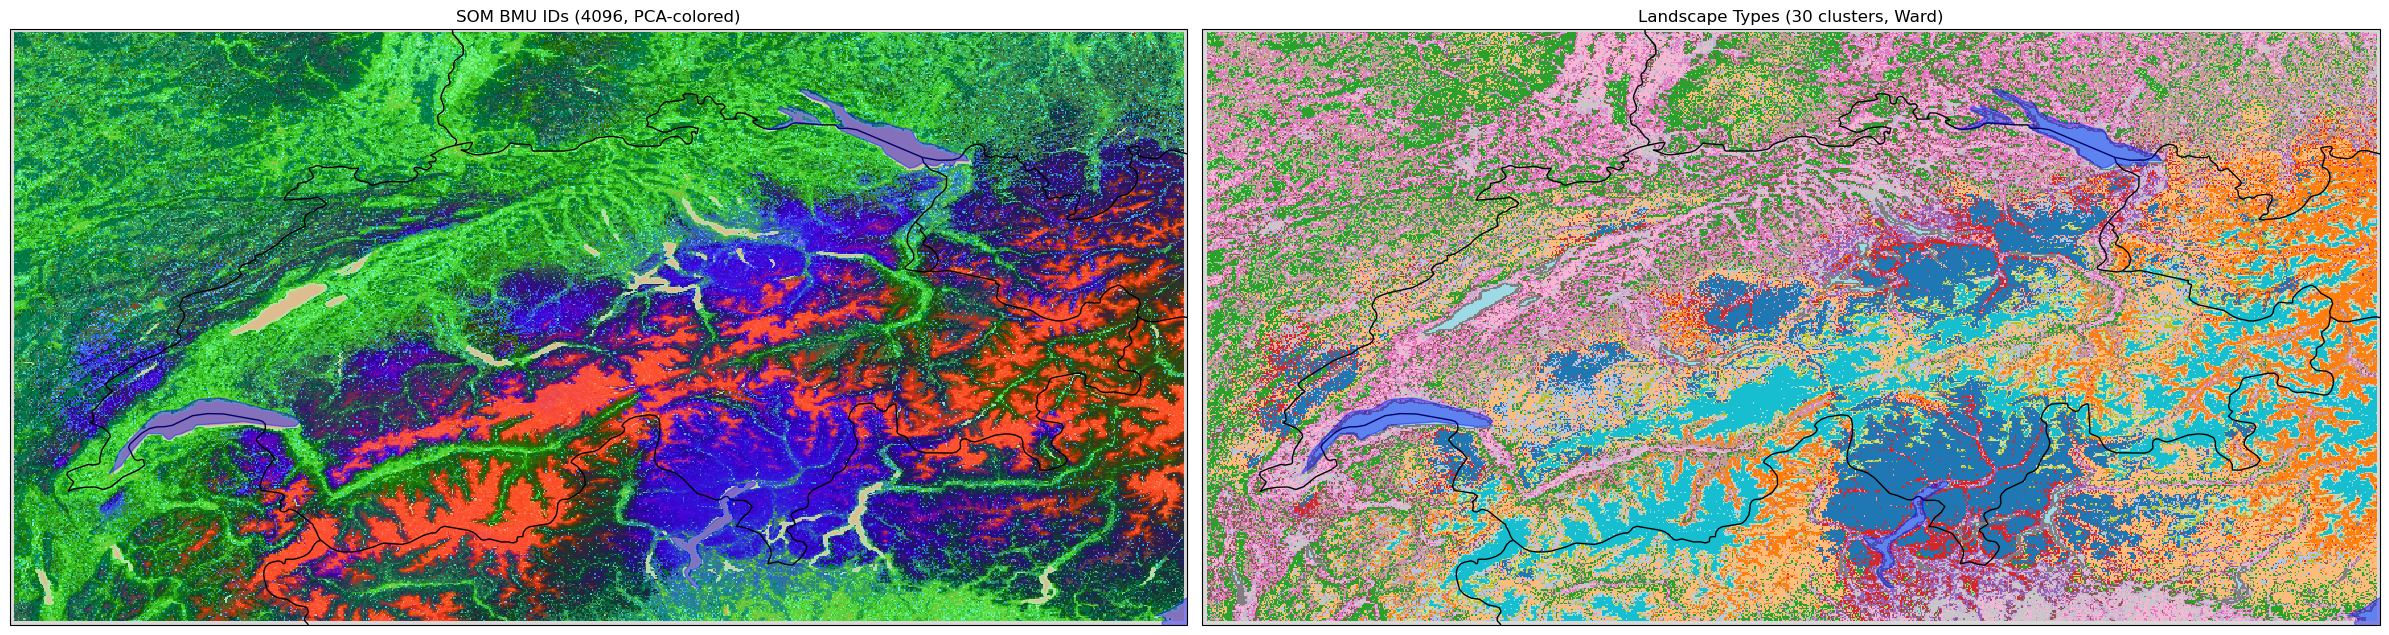

In [8]:
import pickle
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.decomposition import PCA
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from geo_utils import BOUNDS, apply_map_decor

# --- PCA-based colormap for BMU IDs ---
with open('final_som_codebook.pkl', 'rb') as f:
    cb = pickle.load(f)

pca = PCA(n_components=3)
cb_3d = pca.fit_transform(cb)
for c in range(3):
    lo, hi = cb_3d[:, c].min(), cb_3d[:, c].max()
    cb_3d[:, c] = (cb_3d[:, c] - lo) / (hi - lo + 1e-8)

n_units = cb.shape[0]
colors_bmu = np.vstack([[0.85, 0.85, 0.85], cb_3d])
som_cmap = mcolors.ListedColormap(colors_bmu)

# --- Landscape type colormap (tab20 + grey for nodata) ---
n_types = int(cluster_da.values.max()) + 1
base_cm = plt.cm.get_cmap('tab20', n_types)
type_colors = np.vstack([[0.85, 0.85, 0.85], base_cm(np.arange(n_types))[:, :3]])
type_cmap = mcolors.ListedColormap(type_colors)

# --- Downsample for rendering ---
step = 20
bmu_shifted = (patch_da.values + 1)[::step, ::step]
type_shifted = (cluster_da.values + 1)[::step, ::step]

extent = [BOUNDS['lon_min'], BOUNDS['lon_max'],
          BOUNDS['lat_min'], BOUNDS['lat_max']]

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(24, 8),
    subplot_kw={'projection': ccrs.PlateCarree()},
)

# Left: BMU IDs (PCA-colored)
ax1.imshow(bmu_shifted, cmap=som_cmap, vmin=0, vmax=n_units,
           extent=extent, origin='upper', interpolation='nearest',
           transform=ccrs.PlateCarree())
apply_map_decor(ax1, 'SOM BMU IDs (4096, PCA-colored)')

# Right: Landscape types
ax2.imshow(type_shifted, cmap=type_cmap, vmin=0, vmax=n_types,
           extent=extent, origin='upper', interpolation='nearest',
           transform=ccrs.PlateCarree())
apply_map_decor(ax2, f'Landscape Types ({n_types} clusters, Ward)')

plt.tight_layout()
plt.show()


### ROI check: North of Bern

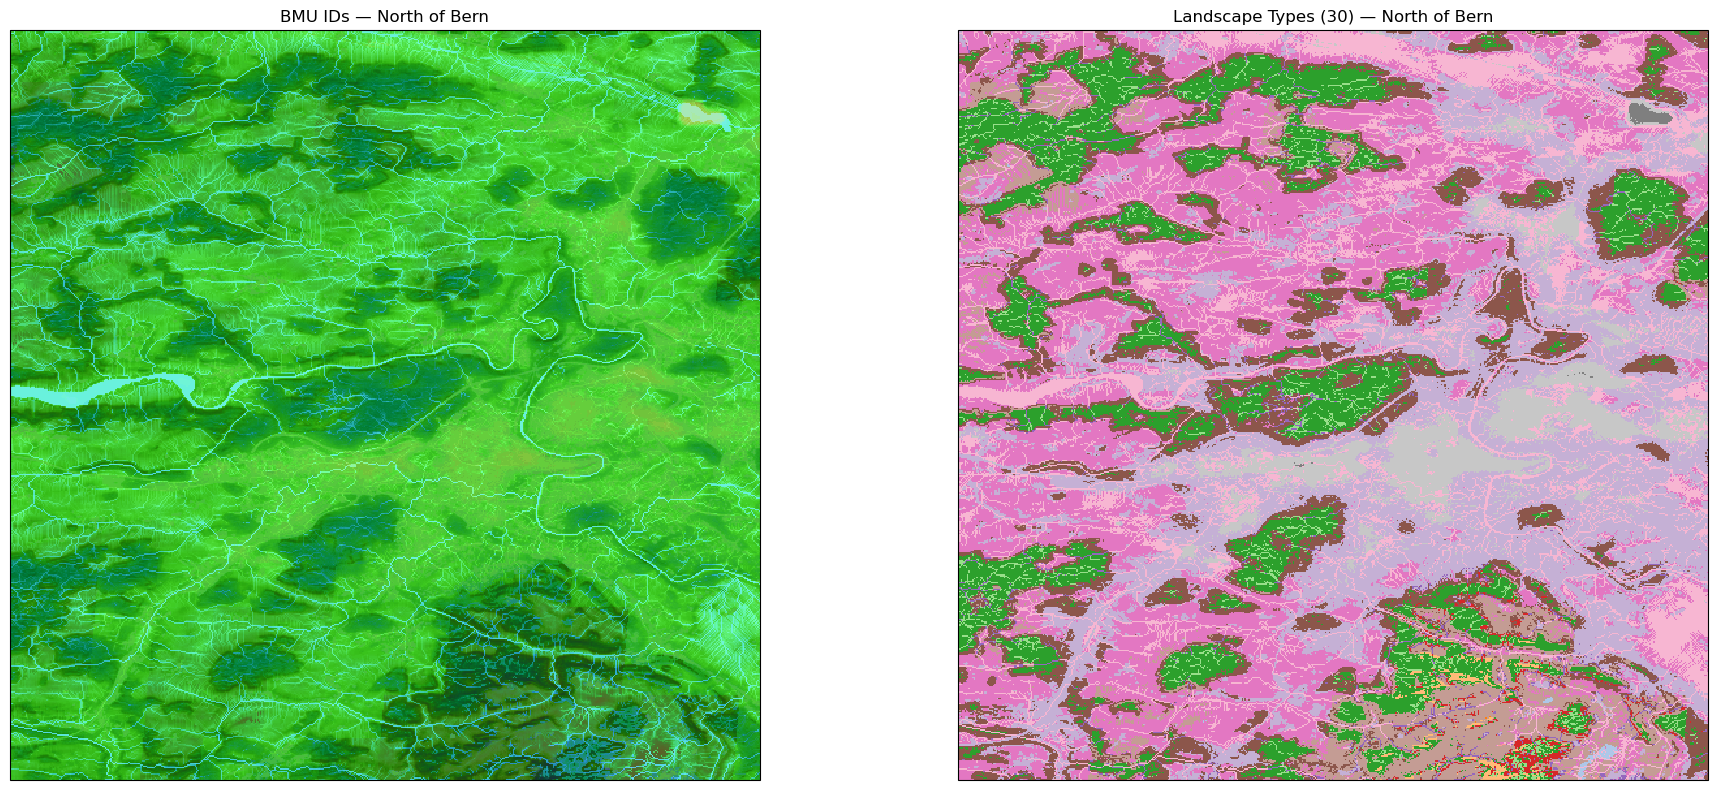

In [9]:
roi_bern = {
    'lon_min': 7.332136, 'lon_max': 7.492136,
    'lat_min': 46.880651, 'lat_max': 47.040651,
}

# Clip both maps to ROI
bmu_roi = patch_da.sel(
    y=slice(roi_bern['lat_max'], roi_bern['lat_min']),
    x=slice(roi_bern['lon_min'], roi_bern['lon_max']),
)
type_roi = cluster_da.sel(
    y=slice(roi_bern['lat_max'], roi_bern['lat_min']),
    x=slice(roi_bern['lon_min'], roi_bern['lon_max']),
)

bmu_shifted = bmu_roi.values + 1
type_shifted = type_roi.values + 1

extent = [roi_bern['lon_min'], roi_bern['lon_max'],
          roi_bern['lat_min'], roi_bern['lat_max']]

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(20, 8),
    subplot_kw={'projection': ccrs.PlateCarree()},
)

# Left: BMU IDs
ax1.imshow(bmu_shifted, cmap=som_cmap, vmin=0, vmax=n_units,
           extent=extent, origin='upper', interpolation='nearest',
           transform=ccrs.PlateCarree())
ax1.add_feature(cfeature.BORDERS.with_scale('10m'), linewidth=0.5)
ax1.add_feature(cfeature.LAKES.with_scale('10m'), alpha=0.3, color='blue')
ax1.set_extent(extent)
ax1.set_title('BMU IDs — North of Bern')

# Right: Landscape types
ax2.imshow(type_shifted, cmap=type_cmap, vmin=0, vmax=n_types,
           extent=extent, origin='upper', interpolation='nearest',
           transform=ccrs.PlateCarree())
ax2.add_feature(cfeature.BORDERS.with_scale('10m'), linewidth=0.5)
ax2.add_feature(cfeature.LAKES.with_scale('10m'), alpha=0.3, color='blue')
ax2.set_extent(extent)
ax2.set_title(f'Landscape Types ({n_types}) — North of Bern')

plt.tight_layout()
plt.show()
